# Liquidity Sweep Detection Benchmark: Hourly, Multi-Timeframe, and Zone-Conditioned Models

This notebook benchmarks multiple modeling strategies for TSLA liquidity sweep prediction:

1. Hourly-only baseline models.
2. Multi-timeframe models that add daily context to hourly inputs.
3. A zone-conditioned buy-vs-sell model for rows where a liquidity zone is present.

Enhancements included in the benchmark:

- class-imbalance handling
- probability calibration and decision-threshold tuning
- a CNN sequence baseline for deep-learning comparison

Outputs produced:

- unified metrics summary table
- confusion-matrix and comparison plots
- exported predictions and result artifacts

## 1. Environment Setup and Reproducibility

This section initializes libraries, random seeds, file paths, and shared helper functions for consistent experiments.

In [22]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

ROOT = Path('.')
DAILY_FILE = ROOT / 'TSLA_results_daily.xlsx'
HOURLY_FILE = ROOT / 'TSLA_results_hourly.xlsx'
OUTPUT_DIR = ROOT / 'outputs' / 'notebook_comparison'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')


def safe_divide(a: pd.Series, b: pd.Series) -> pd.Series:
    b_clean = b.replace(0.0, np.nan)
    out = a / b_clean
    return out.replace([np.inf, -np.inf], np.nan).fillna(0.0)


def summarize_metrics(y_true, y_pred, y_prob=None, model_name='model'):
    row = {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
    }
    if y_prob is not None:
        try:
            row['roc_auc_ovr_macro'] = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
        except Exception:
            row['roc_auc_ovr_macro'] = np.nan
    else:
        row['roc_auc_ovr_macro'] = np.nan
    return row


def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Pred')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

Using device: cpu


## 2. Data Ingestion and Feature Engineering

This section loads daily and hourly datasets, builds derived features, and prepares reusable chronological train/validation/test workflows.

In [23]:
daily_raw = pd.read_excel(DAILY_FILE)
hourly_raw = pd.read_excel(HOURLY_FILE)

print('Daily shape:', daily_raw.shape)
print('Hourly shape:', hourly_raw.shape)


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['Datetime'] = pd.to_datetime(out['Datetime'])
    out = out.sort_values('Datetime').reset_index(drop=True)

    out['return_1'] = out['close'].pct_change().fillna(0.0)
    out['log_return_1'] = np.log(out['close']).diff().fillna(0.0)

    out['candle_range'] = (out['high'] - out['low']).clip(lower=0.0)
    out['body'] = (out['close'] - out['open']).abs()
    out['upper_wick'] = (out['high'] - out[['open', 'close']].max(axis=1)).clip(lower=0.0)
    out['lower_wick'] = (out[['open', 'close']].min(axis=1) - out['low']).clip(lower=0.0)
    out['wick_to_body'] = safe_divide(out['upper_wick'] + out['lower_wick'], out['body'])
    out['upper_wick_ratio'] = safe_divide(out['upper_wick'], out['candle_range'])
    out['lower_wick_ratio'] = safe_divide(out['lower_wick'], out['candle_range'])
    out['close_location'] = safe_divide(out['close'] - out['low'], out['candle_range'])

    out['ema_fast'] = out['close'].ewm(span=8, adjust=False).mean()
    out['ema_slow'] = out['close'].ewm(span=21, adjust=False).mean()
    out['ema_spread'] = safe_divide(out['ema_fast'] - out['ema_slow'], out['close'])

    out['rolling_high_20'] = out['high'].rolling(20).max().bfill()
    out['rolling_low_20'] = out['low'].rolling(20).min().bfill()
    out['break_above_20'] = (out['close'] > out['rolling_high_20'].shift(1)).astype(float).fillna(0.0)
    out['break_below_20'] = (out['close'] < out['rolling_low_20'].shift(1)).astype(float).fillna(0.0)

    out['swept_level'] = out.get('swept_level', 0.0)
    out['swept_level'] = out['swept_level'].fillna(0.0)
    out['distance_from_swept_level'] = safe_divide(out['close'] - out['swept_level'], out['close'])
    out['zone_present'] = out.get('zone_id', pd.Series(index=out.index, data=np.nan)).notna().astype(float)

    if 'volume' not in out.columns:
        out['volume'] = 0.0
    out['volume'] = out['volume'].fillna(0.0)
    out['volume_ma_20'] = out['volume'].rolling(20).mean().bfill()
    out['volume_spike'] = safe_divide(out['volume'], out['volume_ma_20'])

    out['hour'] = out['Datetime'].dt.hour.astype(float)
    out['day_of_week'] = out['Datetime'].dt.dayofweek.astype(float)
    out['hour_sin'] = np.sin(2 * np.pi * out['hour'] / 24.0)
    out['hour_cos'] = np.cos(2 * np.pi * out['hour'] / 24.0)
    out['dow_sin'] = np.sin(2 * np.pi * out['day_of_week'] / 7.0)
    out['dow_cos'] = np.cos(2 * np.pi * out['day_of_week'] / 7.0)

    buy = out['buy_side_sweep'].fillna(False).astype(bool)
    sell = out['sell_side_sweep'].fillna(False).astype(bool)
    out['target'] = np.select([buy, sell], [1, 2], default=0).astype(int)

    return out


def build_daily_context_features(daily_df: pd.DataFrame) -> pd.DataFrame:
    d = build_features(daily_df)
    d['date'] = d['Datetime'].dt.normalize()
    d['daily_buy_side_prev'] = d['buy_side_sweep'].astype(bool).shift(1, fill_value=False).astype(float)
    d['daily_sell_side_prev'] = d['sell_side_sweep'].astype(bool).shift(1, fill_value=False).astype(float)

    keep = [
        'date',
        'return_1', 'log_return_1', 'candle_range', 'body', 'wick_to_body',
        'upper_wick_ratio', 'lower_wick_ratio', 'close_location', 'ema_spread',
        'break_above_20', 'break_below_20', 'distance_from_swept_level',
        'zone_present', 'volume_spike', 'daily_buy_side_prev', 'daily_sell_side_prev'
    ]
    out = d[keep].copy()
    rename_map = {
        c: f'daily_{c}' for c in out.columns
        if c not in {'date', 'daily_buy_side_prev', 'daily_sell_side_prev'}
    }
    return out.rename(columns=rename_map)


def merge_hourly_daily(hourly_df: pd.DataFrame, daily_df: pd.DataFrame) -> pd.DataFrame:
    h = build_features(hourly_df)
    h['date'] = h['Datetime'].dt.normalize()
    dctx = build_daily_context_features(daily_df)
    merged = h.merge(dctx, on='date', how='left')
    daily_cols = [c for c in merged.columns if c.startswith('daily_')]
    if daily_cols:
        merged[daily_cols] = merged[daily_cols].fillna(0.0)
    return merged.sort_values('Datetime').reset_index(drop=True)


hourly_feat = build_features(hourly_raw)
combined_feat = merge_hourly_daily(hourly_raw, daily_raw)

print('Hourly feature frame:', hourly_feat.shape)
print('Combined feature frame:', combined_feat.shape)

Daily shape: (941, 10)
Hourly shape: (6560, 9)
Hourly feature frame: (6560, 38)
Combined feature frame: (6560, 55)


In [24]:
# Reusable split and sequence utilities shared by both approaches.

def make_sequences(df: pd.DataFrame, feature_cols, sequence_length=24):
    x_vals = df[feature_cols].to_numpy(dtype=np.float32)
    y_vals = df['target'].to_numpy(dtype=np.int64)

    x_seq, y_seq, idx = [], [], []
    for i in range(sequence_length - 1, len(df)):
        x_seq.append(x_vals[i-sequence_length+1:i+1])
        y_seq.append(y_vals[i])
        idx.append(i)

    x = np.array(x_seq)
    y = np.array(y_seq)
    idx = np.array(idx)
    return x, y, idx


def split_time_ordered(x, y, idx):
    n = len(y)
    n_train = int(n * 0.70)
    n_val = int(n * 0.15)

    return {
        'x_train': x[:n_train],
        'y_train': y[:n_train],
        'x_val': x[n_train:n_train+n_val],
        'y_val': y[n_train:n_train+n_val],
        'x_test': x[n_train+n_val:],
        'y_test': y[n_train+n_val:],
        'idx_train': idx[:n_train],
        'idx_val': idx[n_train:n_train+n_val],
        'idx_test': idx[n_train+n_val:],
    }


def standardize_split(split):
    mean = split['x_train'].mean(axis=(0, 1), keepdims=True)
    std = split['x_train'].std(axis=(0, 1), keepdims=True)
    std = np.where(std < 1e-6, 1.0, std)

    out = split.copy()
    out['x_train'] = ((split['x_train'] - mean) / std).astype(np.float32)
    out['x_val'] = ((split['x_val'] - mean) / std).astype(np.float32)
    out['x_test'] = ((split['x_test'] - mean) / std).astype(np.float32)
    return out, mean.squeeze(), std.squeeze()

## 3. Hourly Baseline Models

This section trains baseline classifiers on hourly features only:

- Logistic Regression
- Random Forest
- XGBoost (with sklearn fallback when unavailable)

In [25]:
base_hourly_cols = [
    'open', 'high', 'low', 'close', 'volume',
    'return_1', 'log_return_1', 'candle_range', 'body',
    'upper_wick', 'lower_wick', 'wick_to_body',
    'upper_wick_ratio', 'lower_wick_ratio', 'close_location',
    'ema_spread', 'break_above_20', 'break_below_20',
    # Leakage-safe: exclude target-derived columns like distance_from_swept_level and zone_present.
    'volume_spike', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos'
]

# Use same chronological split for fair comparison.
X_hourly = hourly_feat[base_hourly_cols].to_numpy(dtype=np.float32)
y_hourly = hourly_feat['target'].to_numpy(dtype=np.int64)

n = len(y_hourly)
n_train = int(n * 0.70)
n_val = int(n * 0.15)

Xh_train = X_hourly[:n_train]
yh_train = y_hourly[:n_train]
Xh_val = X_hourly[n_train:n_train+n_val]
yh_val = y_hourly[n_train:n_train+n_val]
Xh_test = X_hourly[n_train+n_val:]
yh_test = y_hourly[n_train+n_val:]

# We fit scaler on train only to avoid leakage.
scaler = StandardScaler()
Xh_train_s = scaler.fit_transform(Xh_train)
Xh_val_s = scaler.transform(Xh_val)
Xh_test_s = scaler.transform(Xh_test)

# Class-balanced sample weights help with severe imbalance.
counts = np.bincount(yh_train, minlength=3).astype(float)
counts = np.where(counts == 0, 1.0, counts)
class_weight = {i: counts.sum() / (3 * counts[i]) for i in range(3)}

log_reg = LogisticRegression(
    max_iter=1200,
    class_weight=class_weight,
    random_state=SEED,
)
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    random_state=SEED,
    n_jobs=-1,
)

# Optional XGBoost; fallback to sklearn HistGradientBoosting if unavailable.
try:
    from xgboost import XGBClassifier
    xgb = XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softprob',
        num_class=3,
        random_state=SEED,
        eval_metric='mlogloss',
    )
    xgb_name = 'XGBoost'
except Exception:
    from sklearn.ensemble import HistGradientBoostingClassifier
    xgb = HistGradientBoostingClassifier(
        max_depth=6,
        learning_rate=0.05,
        max_iter=300,
        random_state=SEED,
    )
    xgb_name = 'HistGradientBoosting (fallback)'

non_combined_models = {
    'NonCombined_LogReg': (log_reg, Xh_train_s, Xh_test_s),
    'NonCombined_RandomForest': (rf, Xh_train, Xh_test),
    f'NonCombined_{xgb_name}': (xgb, Xh_train, Xh_test),
}

results = []
pred_store = {}

for name, (model, x_tr, x_te) in non_combined_models.items():
    model.fit(x_tr, yh_train)
    y_pred = model.predict(x_te)
    y_prob = model.predict_proba(x_te) if hasattr(model, 'predict_proba') else None

    results.append(summarize_metrics(yh_test, y_pred, y_prob, name))
    pred_store[name] = {'y_true': yh_test, 'y_pred': y_pred, 'y_prob': y_prob}

print('Leakage-safe non-combined features:', base_hourly_cols)
pd.DataFrame(results).sort_values('f1_macro', ascending=False)

Leakage-safe non-combined features: ['open', 'high', 'low', 'close', 'volume', 'return_1', 'log_return_1', 'candle_range', 'body', 'upper_wick', 'lower_wick', 'wick_to_body', 'upper_wick_ratio', 'lower_wick_ratio', 'close_location', 'ema_spread', 'break_above_20', 'break_below_20', 'volume_spike', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']


,model,accuracy,f1_macro,roc_auc_ovr_macro
1,NonCombined_RandomForest,0.907520,0.459458,0.805630
2,NonCombined_XGBoost,0.926829,0.382637,0.809949
0,NonCombined_LogReg,0.531504,0.355324,0.795472


## 4. Baseline Evaluation

This section reports classification metrics and confusion matrices for each hourly-only baseline model.


NonCombined_LogReg
              precision    recall  f1-score   support

           0     0.9668    0.5121    0.6695       910
           1     0.1098    0.7632    0.1921        38
           2     0.1176    0.7778    0.2044        36

    accuracy                         0.5315       984
   macro avg     0.3981    0.6843    0.3553       984
weighted avg     0.9026    0.5315    0.6341       984



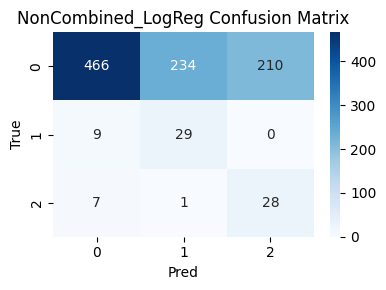


NonCombined_RandomForest
              precision    recall  f1-score   support

           0     0.9352    0.9670    0.9508       910
           1     0.2903    0.2368    0.2609        38
           2     0.3333    0.1111    0.1667        36

    accuracy                         0.9075       984
   macro avg     0.5196    0.4383    0.4595       984
weighted avg     0.8883    0.9075    0.8955       984



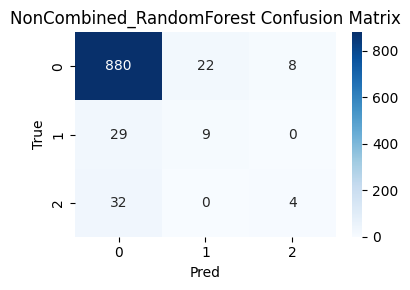


NonCombined_XGBoost
              precision    recall  f1-score   support

           0     0.9284    0.9978    0.9619       910
           1     0.8000    0.1053    0.1860        38
           2     0.0000    0.0000    0.0000        36

    accuracy                         0.9268       984
   macro avg     0.5761    0.3677    0.3826       984
weighted avg     0.8895    0.9268    0.8967       984



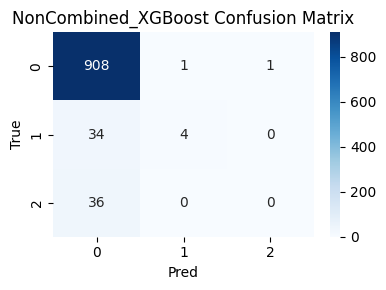

In [26]:
for name, obj in pred_store.items():
    print('\n' + '=' * 80)
    print(name)
    print(classification_report(obj['y_true'], obj['y_pred'], digits=4, zero_division=0))
    plot_confusion(obj['y_true'], obj['y_pred'], f'{name} Confusion Matrix')

## 5. Multi-Timeframe Ensemble (Hourly + Daily Context)

This section builds a combined feature set and trains a stacking ensemble with a logistic meta-learner.

Leakage-safe combined features: ['open', 'high', 'low', 'close', 'volume', 'return_1', 'log_return_1', 'candle_range', 'body', 'upper_wick', 'lower_wick', 'wick_to_body', 'upper_wick_ratio', 'lower_wick_ratio', 'close_location', 'ema_spread', 'break_above_20', 'break_below_20', 'volume_spike', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'daily_return_1', 'daily_log_return_1', 'daily_candle_range', 'daily_body', 'daily_wick_to_body', 'daily_upper_wick_ratio', 'daily_lower_wick_ratio', 'daily_close_location', 'daily_ema_spread', 'daily_break_above_20', 'daily_break_below_20', 'daily_volume_spike']
              precision    recall  f1-score   support

           0     0.9759    0.6681    0.7932       910
           1     0.2015    0.7105    0.3140        38
           2     0.1366    0.8611    0.2357        36

    accuracy                         0.6768       984
   macro avg     0.4380    0.7466    0.4476       984
weighted avg     0.9153    0.6768    0.7543       984



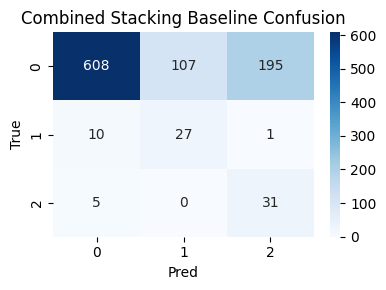

In [27]:
combined_cols = base_hourly_cols + [
    'daily_return_1', 'daily_log_return_1', 'daily_candle_range', 'daily_body',
    'daily_wick_to_body', 'daily_upper_wick_ratio', 'daily_lower_wick_ratio',
    'daily_close_location', 'daily_ema_spread', 'daily_break_above_20',
    'daily_break_below_20',
    # Leakage-safe: exclude daily_distance_from_swept_level, daily_zone_present,
    # and previous-day sweep flags.
    'daily_volume_spike'
]

X_comb = combined_feat[combined_cols].to_numpy(dtype=np.float32)
y_comb = combined_feat['target'].to_numpy(dtype=np.int64)

nc = len(y_comb)
nc_train = int(nc * 0.70)
nc_val = int(nc * 0.15)

Xc_train = X_comb[:nc_train]
yc_train = y_comb[:nc_train]
Xc_val = X_comb[nc_train:nc_train+nc_val]
yc_val = y_comb[nc_train:nc_train+nc_val]
Xc_test = X_comb[nc_train+nc_val:]
yc_test = y_comb[nc_train+nc_val:]

comb_scaler = StandardScaler()
Xc_train_s = comb_scaler.fit_transform(Xc_train)
Xc_val_s = comb_scaler.transform(Xc_val)
Xc_test_s = comb_scaler.transform(Xc_test)

base_estimators = [
    ('lr', LogisticRegression(max_iter=1200, class_weight='balanced', random_state=SEED)),
    ('rf', RandomForestClassifier(n_estimators=300, max_depth=12, class_weight='balanced_subsample', random_state=SEED, n_jobs=-1)),
]

meta = LogisticRegression(max_iter=1200, class_weight='balanced', random_state=SEED)

stack = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta,
    stack_method='predict_proba',
    passthrough=True,
    n_jobs=-1,
)

stack.fit(Xc_train_s, yc_train)
y_pred_stack = stack.predict(Xc_test_s)
y_prob_stack = stack.predict_proba(Xc_test_s)

results.append(summarize_metrics(yc_test, y_pred_stack, y_prob_stack, 'Combined_Stacking_Baseline'))
pred_store['Combined_Stacking_Baseline'] = {
    'y_true': yc_test,
    'y_pred': y_pred_stack,
    'y_prob': y_prob_stack,
}

print('Leakage-safe combined features:', combined_cols)
print(classification_report(yc_test, y_pred_stack, digits=4, zero_division=0))
plot_confusion(yc_test, y_pred_stack, 'Combined Stacking Baseline Confusion')

## 6. Multi-Timeframe Performance Enhancements

Enhancement steps:

- tune tree-based model hyperparameters
- calibrate probability outputs (sigmoid)
- optimize blend weights on validation macro-F1

d:\DSBS\RMSC6007\Project\RMSC6007_Liquidity-Zones\.venv\lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
d:\DSBS\RMSC6007\Project\RMSC6007_Liquidity-Zones\.venv\lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Best blend weight (stack): 0.00, val macro-F1: 0.3393
              precision    recall  f1-score   support

           0     0.9248    1.0000    0.9609       910
           1     0.0000    0.0000    0.0000        38
           2     0.0000    0.0000    0.0000        36

    accuracy                         0.9248       984
   macro avg     0.3083    0.3333    0.3203       984
weighted avg     0.8552    0.9248    0.8887       984



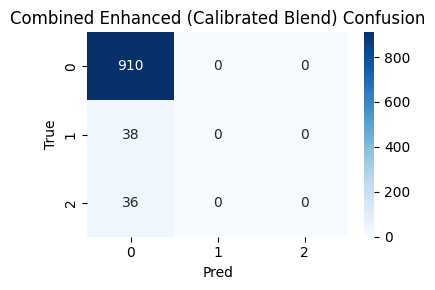

In [28]:
# Tuned random forest on combined features.
rf_tuned = RandomForestClassifier(
    n_estimators=500,
    max_depth=14,
    min_samples_leaf=1,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=SEED,
    n_jobs=-1,
)
rf_tuned.fit(Xc_train, yc_train)

# Calibrate both models using validation set distribution.
stack_cal = CalibratedClassifierCV(stack, method='sigmoid', cv='prefit')
stack_cal.fit(Xc_val_s, yc_val)

rf_cal = CalibratedClassifierCV(rf_tuned, method='sigmoid', cv='prefit')
rf_cal.fit(Xc_val, yc_val)

# Validation probabilities for blend weight selection.
p_stack_val = stack_cal.predict_proba(Xc_val_s)
p_rf_val = rf_cal.predict_proba(Xc_val)

best_w = 0.5
best_f1 = -1.0
for w in np.linspace(0.0, 1.0, 21):
    p_blend = w * p_stack_val + (1.0 - w) * p_rf_val
    pred = p_blend.argmax(axis=1)
    f1 = f1_score(yc_val, pred, average='macro', zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_w = float(w)

print(f'Best blend weight (stack): {best_w:.2f}, val macro-F1: {best_f1:.4f}')

# Evaluate enhanced blend on test set.
p_stack_test = stack_cal.predict_proba(Xc_test_s)
p_rf_test = rf_cal.predict_proba(Xc_test)
p_blend_test = best_w * p_stack_test + (1.0 - best_w) * p_rf_test
y_pred_blend = p_blend_test.argmax(axis=1)

results.append(summarize_metrics(yc_test, y_pred_blend, p_blend_test, 'Combined_Enhanced_CalibratedBlend'))
pred_store['Combined_Enhanced_CalibratedBlend'] = {
    'y_true': yc_test,
    'y_pred': y_pred_blend,
    'y_prob': p_blend_test,
}

print(classification_report(yc_test, y_pred_blend, digits=4, zero_division=0))
plot_confusion(yc_test, y_pred_blend, 'Combined Enhanced (Calibrated Blend) Confusion')

Epoch 01 | Train Loss 5.6600 | Val F1 0.0490
Epoch 02 | Train Loss 4.0457 | Val F1 0.0496
Epoch 03 | Train Loss 3.4283 | Val F1 0.0474
Epoch 04 | Train Loss 2.8450 | Val F1 0.0575
Epoch 05 | Train Loss 2.2427 | Val F1 0.0504
Epoch 06 | Train Loss 1.7948 | Val F1 0.0528
Epoch 07 | Train Loss 1.4861 | Val F1 0.0559
Epoch 08 | Train Loss 1.0530 | Val F1 0.0604
Epoch 09 | Train Loss 0.8732 | Val F1 0.0586
Epoch 10 | Train Loss 0.7935 | Val F1 0.0574
Epoch 11 | Train Loss 0.7393 | Val F1 0.0586
Epoch 12 | Train Loss 0.6183 | Val F1 0.0560
Early stopping triggered.
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       910
           1     0.0660    0.7297    0.1211        37
           2     0.0489    0.8000    0.0921        35

    accuracy                         0.0560       982
   macro avg     0.0383    0.5099    0.0711       982
weighted avg     0.0042    0.0560    0.0078       982



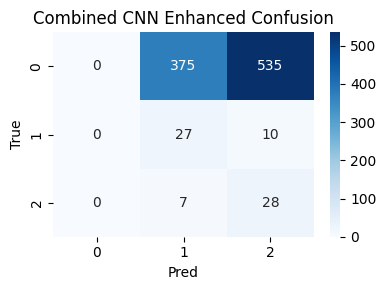

In [ ]:
# Deep-learning benchmark: multi-timeframe CNN with focal loss, weighted sampling, and early stopping.

class SeqDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


class CombinedCNN(nn.Module):
    def __init__(self, n_features, n_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_features, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        return self.net(x)


class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, target):
        ce = nn.functional.cross_entropy(logits, target, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


def evaluate_cnn(model, loader):
    model.eval()
    probs_all, y_all = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            p = torch.softmax(logits, dim=1).cpu().numpy()
            probs_all.append(p)
            y_all.append(yb.numpy())
    y_true = np.concatenate(y_all)
    y_prob = np.concatenate(probs_all)
    y_pred = y_prob.argmax(axis=1)
    return y_true, y_pred, y_prob


# Build sequential dataset for CNN evaluation.
seq_len = 24
x_seq, y_seq, idx_seq = make_sequences(combined_feat, combined_cols, sequence_length=seq_len)
split_seq = split_time_ordered(x_seq, y_seq, idx_seq)
split_seq, mean_seq, std_seq = standardize_split(split_seq)

train_ds = SeqDataset(split_seq['x_train'], split_seq['y_train'])
val_ds = SeqDataset(split_seq['x_val'], split_seq['y_val'])
test_ds = SeqDataset(split_seq['x_test'], split_seq['y_test'])

# Weighted sampling mitigates class imbalance during mini-batch construction.
counts_seq = np.bincount(split_seq['y_train'], minlength=3).astype(float)
counts_seq = np.where(counts_seq == 0, 1.0, counts_seq)
per_class_weight = counts_seq.sum() / (3 * counts_seq)
sample_weights = np.array([per_class_weight[c] for c in split_seq['y_train']], dtype=np.float32)
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=256, sampler=sampler)
val_loader = DataLoader(val_ds, batch_size=512, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=512, shuffle=False)

cnn = CombinedCNN(n_features=len(combined_cols)).to(DEVICE)
alpha = torch.tensor(per_class_weight, dtype=torch.float32, device=DEVICE)
criterion = FocalLoss(alpha=alpha, gamma=2.0)
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)

best_state = None
best_val_f1 = -1.0
patience = 4
wait = 0
max_epochs = 12

for epoch in range(1, max_epochs + 1):
    cnn.train()
    losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = cnn(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    yv_true, yv_pred, _ = evaluate_cnn(cnn, val_loader)
    val_f1 = f1_score(yv_true, yv_pred, average='macro', zero_division=0)
    print(f'Epoch {epoch:02d} | Train Loss {np.mean(losses):.4f} | Val F1 {val_f1:.4f}')

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {k: v.detach().cpu().clone() for k, v in cnn.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print('Early stopping triggered.')
            break

if best_state is not None:
    cnn.load_state_dict(best_state)

yt, yp, yp_prob = evaluate_cnn(cnn, test_loader)
results.append(summarize_metrics(yt, yp, yp_prob, 'Combined_CNN_FocalWeighted_EarlyStop'))
pred_store['Combined_CNN_FocalWeighted_EarlyStop'] = {
    'y_true': yt,
    'y_pred': yp,
    'y_prob': yp_prob,
}

print(classification_report(yt, yp, digits=4, zero_division=0))
plot_confusion(yt, yp, 'Combined CNN Benchmark Confusion Matrix')

## 6b. Decision-Threshold Optimization (Macro-F1)

This section tunes class-specific thresholds on validation probabilities to improve minority-class sweep detection while preserving leakage-safe evaluation.

Combined_Enhanced_ThresholdTuned_StackCal | best thresholds: t1=0.05, t2=0.07 | val macro-F1=0.3841
              precision    recall  f1-score   support

           0     0.9432    0.7846    0.8566       910
           1     0.1471    0.6579    0.2404        38
           2     0.1053    0.1667    0.1290        36

    accuracy                         0.7571       984
   macro avg     0.3985    0.5364    0.4087       984
weighted avg     0.8818    0.7571    0.8062       984

Combined_Enhanced_ThresholdTuned_BlendCal | best thresholds: t1=0.05, t2=0.07 | val macro-F1=0.3841
              precision    recall  f1-score   support

           0     0.9497    0.9132    0.9311       910
           1     0.2857    0.5263    0.3704        38
           2     0.2564    0.2778    0.2667        36

    accuracy                         0.8750       984
   macro avg     0.4973    0.5724    0.5227       984
weighted avg     0.8987    0.8750    0.8851       984

Best threshold-tuned combined model on

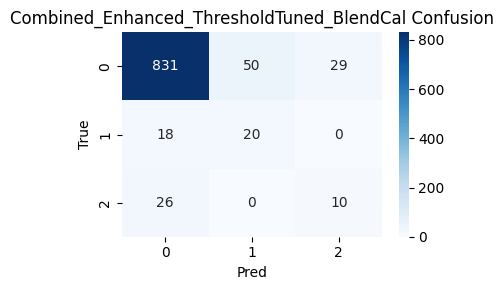

In [30]:
def predict_with_thresholds(proba, t1, t2):
    # Prioritize minority classes when confidence clears tuned thresholds.
    p0 = proba[:, 0]
    p1 = proba[:, 1]
    p2 = proba[:, 2]
    pred = np.zeros(len(proba), dtype=np.int64)

    cond1 = (p1 >= t1) & (p1 >= p2)
    cond2 = (p2 >= t2) & (p2 > p1)

    pred[cond1] = 1
    pred[cond2] = 2

    # If both are false, class 0 remains default.
    return pred


def tune_thresholds(y_true_val, p_val, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.60, 23)

    best = {
        't1': 0.20,
        't2': 0.20,
        'f1': -1.0,
    }

    for t1 in grid:
        for t2 in grid:
            yv = predict_with_thresholds(p_val, t1=t1, t2=t2)
            f1 = f1_score(y_true_val, yv, average='macro', zero_division=0)
            if f1 > best['f1']:
                best = {'t1': float(t1), 't2': float(t2), 'f1': float(f1)}

    return best


# Compare threshold tuning on two combined probability sources.
prob_sources = {
    'Combined_Enhanced_ThresholdTuned_StackCal': (p_stack_val, p_stack_test),
    'Combined_Enhanced_ThresholdTuned_BlendCal': (p_blend, p_blend_test),
}

best_threshold_model = None
best_threshold_result = None

for model_name, (pv, pt) in prob_sources.items():
    best_thr = tune_thresholds(yc_val, pv)
    y_pred_thr = predict_with_thresholds(pt, t1=best_thr['t1'], t2=best_thr['t2'])

    metrics = summarize_metrics(yc_test, y_pred_thr, pt, model_name)

    # Upsert in case this cell is re-run.
    results = [r for r in results if r['model'] != model_name]
    results.append(metrics)

    pred_store[model_name] = {
        'y_true': yc_test,
        'y_pred': y_pred_thr,
        'y_prob': pt,
    }

    print(f"{model_name} | best thresholds: t1={best_thr['t1']:.2f}, t2={best_thr['t2']:.2f} | val macro-F1={best_thr['f1']:.4f}")
    print(classification_report(yc_test, y_pred_thr, digits=4, zero_division=0))

    if best_threshold_result is None or metrics['f1_macro'] > best_threshold_result['f1_macro']:
        best_threshold_result = metrics
        best_threshold_model = model_name

print(f"Best threshold-tuned combined model on test macro-F1: {best_threshold_model} -> {best_threshold_result['f1_macro']:.4f}")
plot_confusion(yc_test, pred_store[best_threshold_model]['y_pred'], f"{best_threshold_model} Confusion")

## 6c. Zone-Conditioned Buy-vs-Sell Classifier

This section trains a side-classifier only on rows with an identified liquidity zone.

- filter to zone-present rows
- keep sweep classes {1, 2}
- train a dedicated classifier to separate buy-side vs sell-side sweeps

Note: this is a conditional task and is not directly comparable to full 3-class detection (0/1/2).

Zone rows: 6409
Zone sweep rows (classes 1/2): 420
Class counts (1=buy, 2=sell):
target
1    202
2    218
Name: count, dtype: int64
              precision    recall  f1-score   support

           1     0.9394    0.9688    0.9538        32
           2     0.9667    0.9355    0.9508        31

    accuracy                         0.9524        63
   macro avg     0.9530    0.9521    0.9523        63
weighted avg     0.9528    0.9524    0.9524        63

Binary ROC-AUC (class 2 vs class 1): 0.9929


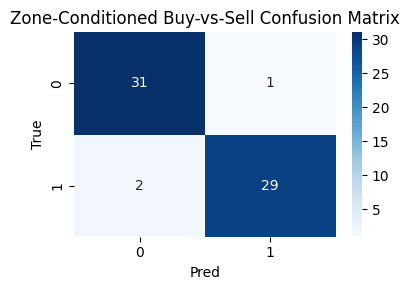

In [34]:
# Zone-conditioned side-classification (buy vs sell).
zone_rows = combined_feat[combined_feat['zone_present'] > 0.5].copy()
zone_sweeps = zone_rows[zone_rows['target'].isin([1, 2])].copy()

print('Zone rows:', len(zone_rows))
print('Zone sweep rows (classes 1/2):', len(zone_sweeps))
print('Class counts (1=buy, 2=sell):')
print(zone_sweeps['target'].value_counts().sort_index())

zone_feature_cols = combined_cols.copy()
X_zone = zone_sweeps[zone_feature_cols].to_numpy(dtype=np.float32)
y_zone = zone_sweeps['target'].to_numpy(dtype=np.int64)

nz = len(y_zone)
nz_train = int(nz * 0.70)
nz_val = int(nz * 0.15)

Xz_train = X_zone[:nz_train]
yz_train = y_zone[:nz_train]
Xz_val = X_zone[nz_train:nz_train+nz_val]
yz_val = y_zone[nz_train:nz_train+nz_val]
Xz_test = X_zone[nz_train+nz_val:]
yz_test = y_zone[nz_train+nz_val:]

if len(np.unique(yz_train)) < 2:
    raise ValueError('Zone-conditioned training split has fewer than two classes. Ensure both buy and sell sweeps exist.')

zone_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    random_state=SEED,
    n_jobs=-1,
)
zone_model.fit(Xz_train, yz_train)

y_pred_zone = zone_model.predict(Xz_test)
y_prob_zone = zone_model.predict_proba(Xz_test)

zone_model_name = 'ZoneConditioned_BuySell_RandomForest'
zone_metrics = summarize_metrics(yz_test, y_pred_zone, y_prob_zone, zone_model_name)

# Binary ROC-AUC for side classification (class 2 treated as positive).
yz_test_bin = (yz_test == 2).astype(int)
if y_prob_zone.shape[1] >= 2:
    zone_metrics['roc_auc_ovr_macro'] = float(roc_auc_score(yz_test_bin, y_prob_zone[:, 1]))

# Upsert supports stable re-execution behavior.
results = [r for r in results if r['model'] != zone_model_name]
results.append(zone_metrics)
pred_store[zone_model_name] = {
    'y_true': yz_test,
    'y_pred': y_pred_zone,
    'y_prob': y_prob_zone,
}

print(classification_report(yz_test, y_pred_zone, digits=4, zero_division=0))
print(f"Binary ROC-AUC (class 2 vs class 1): {zone_metrics['roc_auc_ovr_macro']:.4f}")
plot_confusion(yz_test, y_pred_zone, 'Zone-Conditioned Buy-vs-Sell Confusion Matrix')

## 7. Consolidated Evaluation and Artifact Export

This section aggregates results, visualizes model ranking, and exports metrics and prediction artifacts for reporting.

,model,accuracy,f1_macro,roc_auc_ovr_macro
0,ZoneConditioned_BuySell_RandomForest,0.952381,0.952333,0.992944
1,Combined_Enhanced_ThresholdTuned_BlendCal,0.875000,0.522710,0.849894
2,NonCombined_RandomForest,0.907520,0.459458,0.805630
3,Combined_Stacking_Baseline,0.676829,0.447637,0.838499
4,Combined_Enhanced_ThresholdTuned_StackCal,0.757114,0.408682,0.795594
5,NonCombined_XGBoost,0.926829,0.382637,0.809949
6,NonCombined_LogReg,0.531504,0.355324,0.795472
7,Combined_Enhanced_CalibratedBlend,0.924797,0.320310,0.849894
8,Combined_CNN_FocalWeighted_EarlyStop,0.056008,0.071060,0.641777


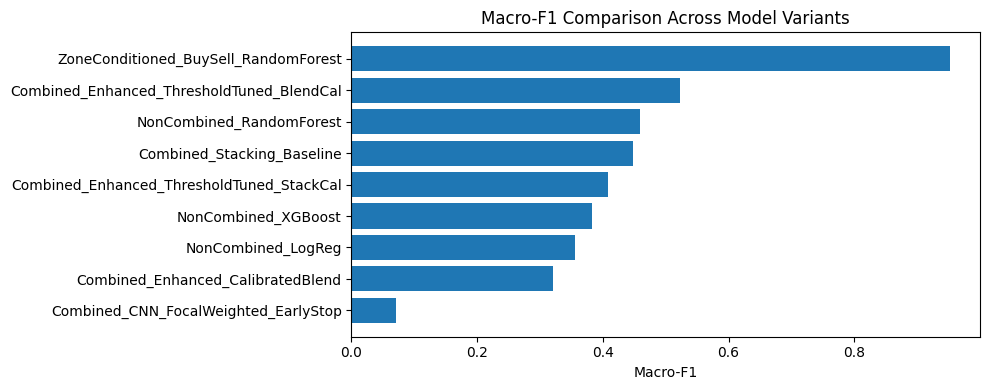

Best hourly-only baseline:


,model,accuracy,f1_macro,roc_auc_ovr_macro
2,NonCombined_RandomForest,0.90752,0.459458,0.80563


Best multi-timeframe model:


,model,accuracy,f1_macro,roc_auc_ovr_macro
1,Combined_Enhanced_ThresholdTuned_BlendCal,0.875,0.52271,0.849894


Best zone-conditioned side-classifier:


,model,accuracy,f1_macro,roc_auc_ovr_macro
0,ZoneConditioned_BuySell_RandomForest,0.952381,0.952333,0.992944


Multi-timeframe minus hourly-only macro-F1 delta: +0.0633
Saved: outputs\notebook_comparison\comparison_metrics.csv
Saved: outputs\notebook_comparison\comparison_metrics.json
Saved: outputs\notebook_comparison\best_model_predictions_ZoneConditioned_BuySell_RandomForest.csv


In [38]:
results_df = pd.DataFrame(results)

# Normalize legacy labels from earlier runs to canonical names.
label_map = {
    'ZoneOnly_BuySell_RF_CombinedFeatures': 'ZoneConditioned_BuySell_RandomForest',
    'Combined_CNN_FocalSampler_EarlyStop': 'Combined_CNN_FocalWeighted_EarlyStop',
}
results_df['model'] = results_df['model'].replace(label_map)

# Keep only the latest entry per model name when cells are re-executed multiple times.
results_df = results_df.drop_duplicates(subset=['model'], keep='last')
results_df = results_df.sort_values('f1_macro', ascending=False).reset_index(drop=True)
display(results_df)

plt.figure(figsize=(10, 4))
plot_df = results_df.copy()
plot_df = plot_df.sort_values('f1_macro', ascending=True)
plt.barh(plot_df['model'], plot_df['f1_macro'])
plt.title('Macro-F1 Comparison Across Model Variants')
plt.xlabel('Macro-F1')
plt.tight_layout()
plt.show()

# Report best models by evaluation family.
best_non_combined = results_df[results_df['model'].str.startswith('NonCombined_')].head(1)
best_combined = results_df[results_df['model'].str.startswith('Combined_')].head(1)
best_zone_conditioned = results_df[results_df['model'].str.startswith('ZoneConditioned_')].head(1)

print('Best hourly-only baseline:')
display(best_non_combined)
print('Best multi-timeframe model:')
display(best_combined)
print('Best zone-conditioned side-classifier:')
display(best_zone_conditioned)

if not best_non_combined.empty and not best_combined.empty:
    delta = float(best_combined.iloc[0]['f1_macro'] - best_non_combined.iloc[0]['f1_macro'])
    print(f'Multi-timeframe minus hourly-only macro-F1 delta: {delta:+.4f}')

# Save artifacts for reporting.
results_path = OUTPUT_DIR / 'comparison_metrics.csv'
summary_path = OUTPUT_DIR / 'comparison_metrics.json'

results_df.to_csv(results_path, index=False)
summary_path.write_text(results_df.to_json(orient='records', indent=2), encoding='utf-8')

# Export predictions for the top-ranked model in the table.
best_name = results_df.iloc[0]['model']
best_obj = pred_store[best_name] if best_name in pred_store else pred_store['ZoneConditioned_BuySell_RandomForest']
pred_out = pd.DataFrame({
    'y_true': best_obj['y_true'],
    'y_pred': best_obj['y_pred'],
})
if best_obj['y_prob'] is not None:
    for k in range(best_obj['y_prob'].shape[1]):
        pred_out[f'prob_class_{k}'] = best_obj['y_prob'][:, k]

pred_path = OUTPUT_DIR / f'best_model_predictions_{best_name}.csv'
pred_out.to_csv(pred_path, index=False)

print(f'Saved: {results_path}')
print(f'Saved: {summary_path}')
print(f'Saved: {pred_path}')

In [36]:
# Diagnostic summary: key drivers and empirical sweep conditions.

# 1) Feature importance from the zone-conditioned Random Forest classifier.
zone_imp = pd.DataFrame({
    'feature': zone_feature_cols,
    'importance': zone_model.feature_importances_,
}).sort_values('importance', ascending=False)

print('Top 12 features for ZoneConditioned_BuySell_RandomForest:')
print(zone_imp.head(12).to_string(index=False))

# 2) Class-profile comparison for sweep (1/2) versus no-sweep (0).
profile_cols = ['candle_range', 'wick_to_body', 'upper_wick_ratio', 'lower_wick_ratio', 'ema_spread', 'break_above_20', 'break_below_20', 'volume_spike']
profile_df = combined_feat[['target'] + profile_cols].copy()
profile_df['is_sweep'] = (profile_df['target'] != 0).astype(int)

agg = profile_df.groupby('is_sweep')[profile_cols].median().T
agg.columns = ['no_sweep_median', 'sweep_median']
agg['delta_sweep_minus_no'] = agg['sweep_median'] - agg['no_sweep_median']

print('\nMedian profile differences (sweep vs no-sweep):')
print(agg.sort_values('delta_sweep_minus_no', ascending=False).to_string())

# 3) Decision rule from the tuned combined detector.
print('\nOperational thresholds from tuned multi-timeframe detector:')
print('predict buy-sweep if p(class=1) >= 0.05 and p1 >= p2')
print('predict sell-sweep if p(class=2) >= 0.07 and p2 > p1')
print('otherwise predict no-sweep')

Top 12 features for ZoneConditioned_BuySell_RandomForest:
               feature  importance
        close_location    0.199396
            ema_spread    0.142349
      lower_wick_ratio    0.054618
              return_1    0.047109
          log_return_1    0.045375
      upper_wick_ratio    0.037848
    daily_log_return_1    0.037419
        daily_return_1    0.036934
            lower_wick    0.030689
      daily_ema_spread    0.029245
            upper_wick    0.028188
daily_lower_wick_ratio    0.026435

Median profile differences (sweep vs no-sweep):
                  no_sweep_median  sweep_median  delta_sweep_minus_no
candle_range             2.860000      3.820000              0.960000
ema_spread               0.000436      0.001059              0.000623
break_above_20           0.000000      0.000000              0.000000
break_below_20           0.000000      0.000000              0.000000
volume_spike             0.000000      0.000000              0.000000
upper_wick_ratio  